In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pipeline = joblib.load('../models/tier_classifier.pkl')
metadata = joblib.load('../models/tier_metadata.pkl')

In [3]:
def elastic_drive_engine(datos_coche, demanda=0, stock_rival=0, dias_stock=0):
    """
    Simula el comportamiento de la App:
    1. Predice Tier.
    2. Busca precio base.
    3. Aplica ajustes dinámicos de mercado.
    """
    # A. Clasificación IA
    tier = pipeline.predict(datos_coche)[0]
    precio_base = metadata[tier]['median_price']

    # B. Lógica de Pricing Dinámico (Elasticidad)
    # Tasa de depreciación mensual (2%)
    f_tiempo = (1 - 0.02) ** (dias_stock / 30)

    # Factor de mercado (Demanda vs Competencia)
    # Si demanda > stock_rival, precio sube.
    elast = 0.3 # Coeficiente de elasticidad
    f_mercado = 1 + (elast * ((demanda/100) - (stock_rival/100)))

    precio_final = precio_base * f_tiempo * f_mercado

    return {
        'Tier': tier,
        'Precio Base': round(precio_base, 2),
        'Precio Elastic': round(precio_final, 2),
        'Impacto %': round(((precio_final/precio_base)-1)*100, 2)
    }

In [4]:
escenarios = [
    {
        'Nombre': 'Caso A: Pickup Premium Seminueva (Alta Demanda)',
        'Datos': pd.DataFrame([{
            'manufacturer': 'ford', 'model': 'Ford F-150', 'year': 2023, 'odometer': 10000,
            'cylinders_num': 8, 'fuel': 'gas', 'drive': '4wd', 'transmission': 'automatic',
            'type': 'pickup', 'paint_color': 'white', 'condition': 'like new'
        }]),
        'Mercado': {'demanda': 40, 'stock_rival': -20, 'dias_stock': 5}
    },
    {
        'Nombre': 'Caso B: Sedán Viejo con Mucho Stock (Baja Demanda)',
        'Datos': pd.DataFrame([{
            'manufacturer': 'toyota', 'model': 'Toyota Camry', 'year': 2008, 'odometer': 180000,
            'cylinders_num': 4, 'fuel': 'gas', 'drive': 'fwd', 'transmission': 'automatic',
            'type': 'sedan', 'paint_color': 'silver', 'condition': 'fair'
        }]),
        'Mercado': {'demanda': -30, 'stock_rival': 50, 'dias_stock': 90}
    }
]

In [7]:
escenarios_extra = [
    {
        'Nombre': 'Caso C: Tier 3 - Pickup Estándar (Mercado Estable)',
        'Datos': pd.DataFrame([{
            'manufacturer': 'chevrolet', 'model': 'Silverado 1500', 'year': 2015, 'odometer': 110000,
            'cylinders_num': 8, 'fuel': 'gas', 'drive': '4wd', 'transmission': 'automatic',
            'type': 'pickup', 'paint_color': 'black', 'condition': 'good'
        }]),
        'Mercado': {'demanda': 5, 'stock_rival': 5, 'dias_stock': 15} # Mercado neutro
    },
    {
        'Nombre': 'Caso D: Tier 1 - Fin de Vida Útil (Liquidación)',
        'Datos': pd.DataFrame([{
            'manufacturer': 'ford', 'model': 'Ford F-150', 'year': 2002, 'odometer': 250000,
            'cylinders_num': 6, 'fuel': 'gas', 'drive': 'rwd', 'transmission': 'automatic',
            'type': 'pickup', 'paint_color': 'white', 'condition': 'fair'
        }]),
        'Mercado': {'demanda': -10, 'stock_rival': 10, 'dias_stock': 120} # Mucho tiempo parado
    },
    {
        'Nombre': 'Caso E: El "Unicornio" (Viejo pero nuevo)',
        'Datos': pd.DataFrame([{
            'manufacturer': 'toyota', 'model': 'Toyota Camry', 'year': 2005, 'odometer': 20000,
            'cylinders_num': 4, 'fuel': 'gas', 'drive': 'fwd', 'transmission': 'automatic',
            'type': 'sedan', 'paint_color': 'gold', 'condition': 'excellent'
        }]),
        'Mercado': {'demanda': 20, 'stock_rival': -10, 'dias_stock': 2}
    },
    {
        'Nombre': 'Caso F: El "Castigado" (Nuevo pero quemado)',
        'Datos': pd.DataFrame([{
            'manufacturer': 'ford', 'model': 'Ford F-150', 'year': 2021, 'odometer': 160000,
            'cylinders_num': 6, 'fuel': 'gas', 'drive': '4wd', 'transmission': 'automatic',
            'type': 'pickup', 'paint_color': 'white', 'condition': 'good'
        }]),
        'Mercado': {'demanda': 0, 'stock_rival': 0, 'dias_stock': 30}
    }
]

In [5]:
print("🚀 INICIANDO TEST DE ESTRÉS: ELASTIC DRIVE ENGINE\n")

for e in escenarios:
    res = elastic_drive_engine(e['Datos'], **e['Mercado'])
    print(f"📌 {e['Nombre']}")
    print(f"   - Resultado IA: Tier {res['Tier']}")
    print(f"   - Precio Base (Estático): ${res['Precio Base']:,}")
    print(f"   - Precio Ajustado (Elastic): ${res['Precio Elastic']:,}")
    print(f"   - Variación: {res['Impacto %']}%\n")

🚀 INICIANDO TEST DE ESTRÉS: ELASTIC DRIVE ENGINE

📌 Caso A: Pickup Premium Seminueva (Alta Demanda)
   - Resultado IA: Tier 4
   - Precio Base (Estático): $36,000
   - Precio Ajustado (Elastic): $42,337.21
   - Variación: 17.6%

📌 Caso B: Sedán Viejo con Mucho Stock (Baja Demanda)
   - Resultado IA: Tier 2
   - Precio Base (Estático): $8,500
   - Precio Ajustado (Elastic): $6,080.1
   - Variación: -28.47%



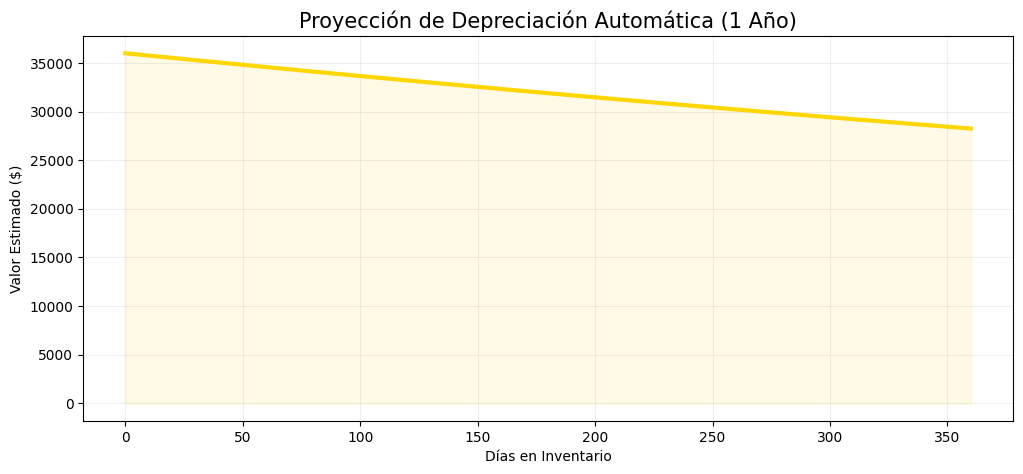

In [6]:
dias = np.arange(0, 365, 10)
precios_evolucion = []
# Usamos el coche del Caso A para ver cómo muere su valor en un año
for d in dias:
    p = elastic_drive_engine(escenarios[0]['Datos'], dias_stock=d)['Precio Elastic']
    precios_evolucion.append(p)

plt.figure(figsize=(12, 5))
plt.plot(dias, precios_evolucion, color='gold', linewidth=3, label='Valor del Activo')
plt.fill_between(dias, precios_evolucion, alpha=0.1, color='gold')
plt.title('Proyección de Depreciación Automática (1 Año)', fontsize=15)
plt.xlabel('Días en Inventario')
plt.ylabel('Valor Estimado ($)')
plt.grid(True, alpha=0.2)
plt.show()

In [8]:
for e in escenarios_extra:
    res = elastic_drive_engine(e['Datos'], **e['Mercado'])
    print(f"📌 {e['Nombre']}")
    print(f"   - Resultado IA: Tier {res['Tier']}")
    print(f"   - Precio Base: ${res['Precio Base']:,} | Final: ${res['Precio Elastic']:,}")
    print(f"   - Variación: {res['Impacto %']}%\n")

📌 Caso C: Tier 3 - Pickup Estándar (Mercado Estable)
   - Resultado IA: Tier 3
   - Precio Base: $21,000 | Final: $20,788.94
   - Variación: -1.01%

📌 Caso D: Tier 1 - Fin de Vida Útil (Liquidación)
   - Resultado IA: Tier 1
   - Precio Base: $7,900 | Final: $6,849.51
   - Variación: -13.3%

📌 Caso E: El "Unicornio" (Viejo pero nuevo)
   - Resultado IA: Tier 2
   - Precio Base: $8,500 | Final: $9,252.53
   - Variación: 8.85%

📌 Caso F: El "Castigado" (Nuevo pero quemado)
   - Resultado IA: Tier 3
   - Precio Base: $21,000 | Final: $20,580.0
   - Variación: -2.0%



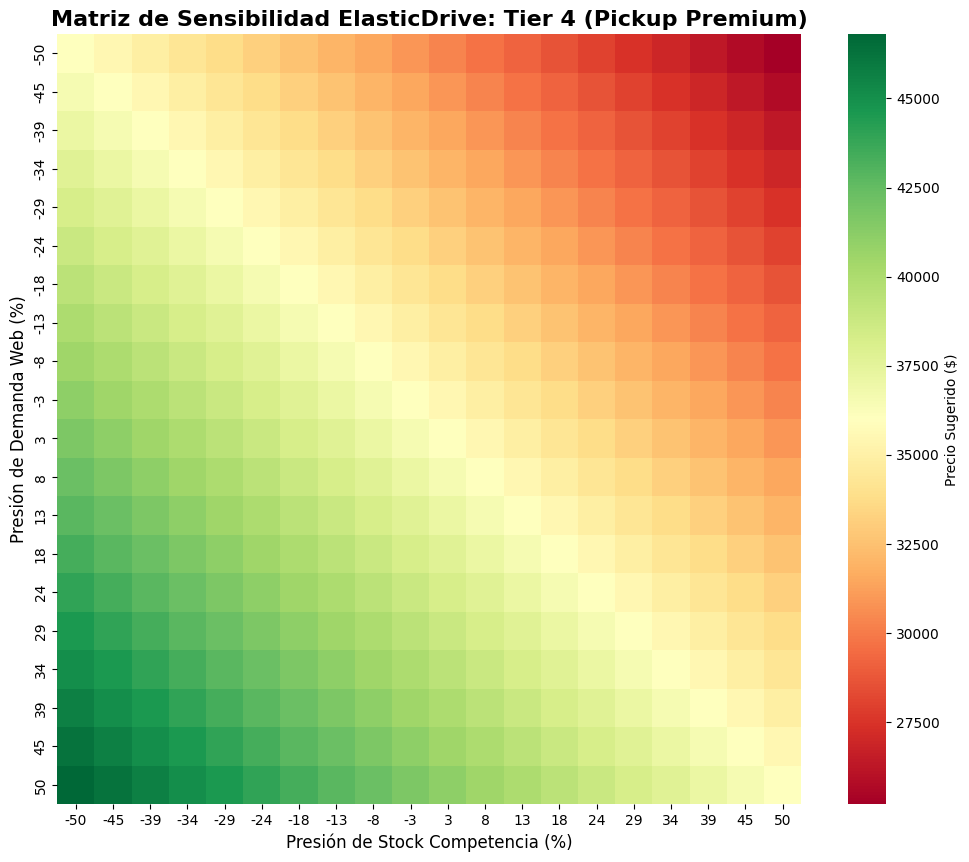

In [9]:
coche_premium = escenarios[0]['Datos']
precio_base_premium = metadata[4]['median_price']

# Creamos rangos de Demanda y Stock (de -50% a +50%)
rango_demanda = np.linspace(-50, 50, 20)
rango_stock = np.linspace(-50, 50, 20)

# Matriz para guardar los precios finales
matriz_precios = np.zeros((len(rango_demanda), len(rango_stock)))

for i, d in enumerate(rango_demanda):
    for j, s in enumerate(rango_stock):
        # Calculamos el precio para cada combinación (asumiendo 0 días en stock)
        res = elastic_drive_engine(coche_premium, demanda=d, stock_rival=s, dias_stock=0)
        matriz_precios[i, j] = res['Precio Elastic']

# Dibujamos el Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_precios,
    xticklabels=np.round(rango_stock, 0).astype(int),
    yticklabels=np.round(rango_demanda, 0).astype(int),
    cmap='RdYlGn', # Rojo (Barato) -> Amarillo -> Verde (Caro)
    annot=False,
    cbar_kws={'label': 'Precio Sugerido ($)'}
)

plt.title('Matriz de Sensibilidad ElasticDrive: Tier 4 (Pickup Premium)', fontsize=16, fontweight='bold')
plt.xlabel('Presión de Stock Competencia (%)', fontsize=12)
plt.ylabel('Presión de Demanda Web (%)', fontsize=12)
plt.show()